In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from scipy.stats import pearsonr

In [13]:
#load the data set
new = pd.read_csv("C:/Data/new.csv")

In [2]:
Amazone = pd.read_csv("C:/Data/yfinance_data/Data/AMZN.csv")

In [14]:
new['date'] = pd.to_datetime(new['date'], errors='coerce')

In [15]:
new['news_date'] = new['date'].dt.date

In [17]:
trading_days = Amazone['Date'].sort_values().unique()

In [18]:
new['date'] = pd.to_datetime(new['date']).dt.tz_localize(None)
Amazone['Date'] = pd.to_datetime(Amazone['Date']).dt.tz_localize(None)

In [19]:
new['date'].isna().sum()

np.int64(1351341)

In [20]:
new = new.sort_values('date')
Amazone = Amazone.sort_values('Date')

In [4]:

print(new.head())

         Date  Close    High     Low    Open     Volume
0  2009-01-02  2.718  2.7265  2.5535  2.5675  145928000
1  2009-01-05  2.703  2.7870  2.6515  2.7865  190196000
2  2009-01-06  2.868  2.9110  2.6875  2.7275  221602000
3  2009-01-07  2.810  2.8475  2.7675  2.8145  158854000
4  2009-01-08  2.858  2.8660  2.7290  2.7495  131558000


In [5]:
Amazone['Date'] = pd.to_datetime(Amazone['Date'],errors='coerce')

In [6]:
Amazone['Date_only'] = Amazone['Date'].dt.date

In [7]:
Amazone['Date'] = pd.to_datetime(Amazone['Date']).dt.tz_localize(None)

In [9]:
Amazone['Date'].isna().sum()

np.int64(0)

In [10]:
Amazone[Amazone['Date'].isna()]

,Date,Close,High,Low,Open,Volume,Date_only


In [22]:
new['date'].isna().sum()

np.int64(1351341)

In [24]:
new = new.dropna(subset=['date'])
Amazone = Amazone.dropna(subset=['Date'])

In [25]:
new['date'] = pd.to_datetime(new['date'])
Amazone['Date'] = pd.to_datetime(Amazone['Date'])

In [26]:
new = new.sort_values('date')
Amazone = Amazone.sort_values('Date')

In [27]:
result = pd.merge_asof(
    new,
    Amazone,
    left_on='date',
    right_on='Date'
)

In [28]:
trading_days = pd.to_datetime(Amazone['Date']).drop_duplicates().sort_values()

s = pd.Series(trading_days, index=trading_days)

def align(date):
    date = pd.to_datetime(date)
    future_days = trading_days[trading_days >= date]
    return future_days.iloc[0] if len(future_days) else None

new['aligned_date'] = new['date'].apply(align)

In [29]:
#Apply sentiment scoring
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

new['sentiment'] = new['headline'].apply(
    lambda x: sia.polarity_scores(x)['compound']
)

In [31]:
#Aggregate Daily Sentiment
daily_sentiment = new.groupby(['stock', 'aligned_date'])['sentiment'].mean().reset_index()

In [32]:
#Calculate Daily Stock Returns
Amazone = Amazone.sort_values('Date')

Amazone['daily_return'] = Amazone['Close'].pct_change() * 100

In [33]:
#Merge Sentiment + Stock Data
merged = pd.merge(
    daily_sentiment,
    Amazone,
    left_on='aligned_date',
    right_on='Date',
    how='inner'
)

In [34]:
#Correlation Analysis
from scipy.stats import pearsonr

corr, p_value = pearsonr(merged['sentiment'], merged['daily_return'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.0036314138012454745
P-value: 0.44573586429036816


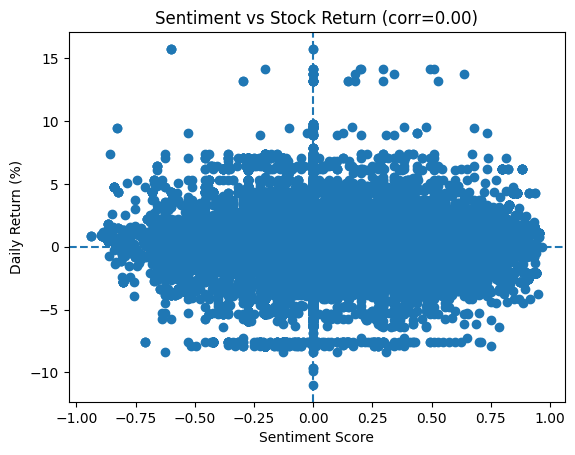

In [35]:
#Scatter Plot
import matplotlib.pyplot as plt

plt.scatter(merged['sentiment'], merged['daily_return'])
plt.xlabel("Sentiment Score")
plt.ylabel("Daily Return (%)")
plt.title(f"Sentiment vs Stock Return (corr={corr:.2f})")
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")
plt.show()

In [36]:
#Sentiment Classification
def label_sentiment(x):
    if x > 0.05:
        return "Positive"
    elif x < -0.05:
        return "Negative"
    return "Neutral"

merged['sentiment_label'] = merged['sentiment'].apply(label_sentiment)

In [37]:
#Bar Chart (Average Return per Sentiment)
avg_returns = merged.groupby('sentiment_label')['daily_return'].mean().reset_index()

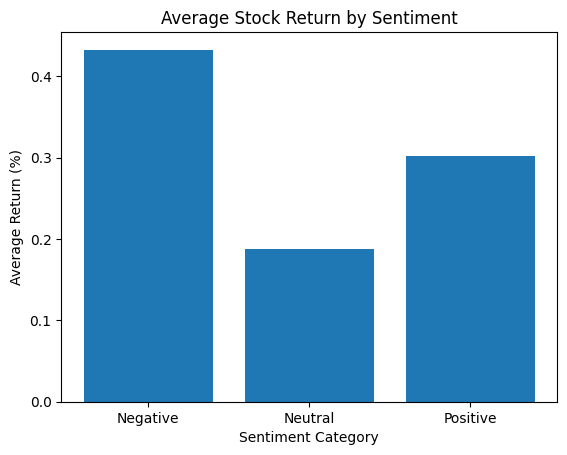

In [38]:
plt.bar(avg_returns['sentiment_label'], avg_returns['daily_return'])
plt.title("Average Stock Return by Sentiment")
plt.xlabel("Sentiment Category")
plt.ylabel("Average Return (%)")
plt.show()